## Predicciones y análsis de las predicciones.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import balanced_accuracy_score, classification_report, roc_auc_score, roc_curve
from utils.model import open_optimized_model, get_best_model_name
from constants.separated import ( 
    X_val,
    y_val, 
    X_test,
)
from constants.scaled import (
    X_val_scaled, X_test_scaled,
    y_val_scaled
)
import os
from constants.directories import predicted_dir
import numpy as np

In [2]:
# Load the optimized model
optimized_model = open_optimized_model()
print("Loading optimized model...")

Loading optimized model...


In [3]:
model_name = get_best_model_name()
print(f"Model name: {model_name}")

Model name: xgb1


In [4]:
# Determine if model uses scaled data
use_scaled_data = any(name in model_name for name in ['rf4', 'rf5', 'rf6', 'xgb2'])

# Select appropriate data based on model type
if use_scaled_data:
    print("Using scaled data for evaluation")
    X_eval = X_val_scaled
    y_eval = y_val_scaled
else:
    print("Using unscaled data for evaluation")
    X_eval = X_val
    y_eval = y_val

# Evaluate model
print("\nEvaluating optimized model:")
print("-" * 50)

Using unscaled data for evaluation

Evaluating optimized model:
--------------------------------------------------


In [5]:
# Evaluate model
print(f"\nEvaluating optimized model:")
print("-" * 50)


Evaluating optimized model:
--------------------------------------------------


Hacemos las predicciones

In [6]:
y_pred = optimized_model.predict(X_eval)
y_proba = optimized_model.predict_proba(X_eval)[:, 1]


Calculamos las metricas

In [7]:
bal_acc = balanced_accuracy_score(y_eval, y_pred)
auc = roc_auc_score(y_eval, y_proba)

print(f"Balanced Accuracy: {bal_acc:.4f}")
print(f"AUC: {auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_eval, y_pred))

Balanced Accuracy: 0.9244
AUC: 0.9835

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     38059
           1       0.77      0.86      0.81      1223

    accuracy                           0.99     39282
   macro avg       0.88      0.92      0.90     39282
weighted avg       0.99      0.99      0.99     39282



Generamos las predicciones

In [8]:
X_test_final = X_test_scaled if use_scaled_data else X_test
y_test_pred = optimized_model.predict(X_test_final)

Guardamos las predicciones en un csv

In [9]:
os.makedirs(predicted_dir, exist_ok=True)
pd.DataFrame(y_test_pred, columns=['predicted']).to_csv(
    f"{predicted_dir}/vehiculos_test_preds_optimized.csv", 
    index=False
)

In [10]:
print(f"\nPredictions saved to: {predicted_dir}/vehiculos_test_preds_optimized.csv")
print(f"Fraudulent transactions: {y_test_pred.sum()}")


Predictions saved to: ./datos/6. predichos/vehiculos_test_preds_optimized.csv
Fraudulent transactions: 757


Procedmos a greaficar la curva ROC del mejor modelo optimizado.

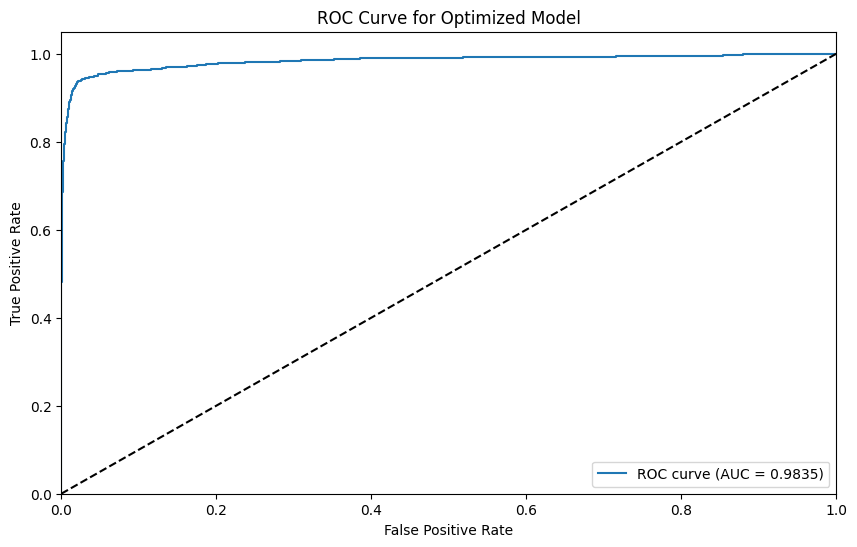

In [11]:
plt.figure(figsize=(10, 6))
fpr, tpr, _ = roc_curve(y_eval, y_proba)
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Optimized Model')
plt.legend(loc="lower right")
plt.show()

Creamos un sistema versátil porque durante las iteraciones realizadas han ganado diferentes modelos entre los que usan datos normalizados y los que tienen las magnitudes originales. En esta ocasion ha ganado xgb1 a pesar de xgb2 tuvo el mismo rendimiento, esto nos ha demostrado que el escalado de los datos no influyó en el rendimiento del modelo a pesar de que le pusimos una ponderacion al tiempo en el que modelo tarda en converger para elegir el mejor modelo a optimizar.

No sería sorpresa que mediante el ajuste de varaibles predictoras o se codifique alguna que no fue tomada en cuenta, el ganador sea un RandomForestClassifier.

Este entorno de control de versiones nos permite realizar dichas experimentaciones.

En esta iteracion haber puesto a probar 50 combinaciones fue demasiado puesto que en la iteracion 14 se llegó a 0.93 de accurary balance. Por lo que no vimos sentido experimentar con 100 o 200.


### Valores predichos vs. reales en el proceso de validacion

Vemos cuan bueno es nuestro modelo detectando casos de fraude

In [12]:
if isinstance(y_eval, pd.DataFrame):
    y_eval_array = y_eval.values.flatten()
else:
    y_eval_array = y_eval

if isinstance(y_pred, pd.DataFrame):
    y_pred_array = y_pred.values.flatten()
else:
    y_pred_array = y_pred

fraud_mask = (y_eval_array == 1)
total_fraud = sum(fraud_mask)
correctly_predicted = sum((y_eval_array == 1) & (y_pred_array == 1))
missed_fraud = sum((y_eval_array == 1) & (y_pred_array == 0))
detection_rate = correctly_predicted / total_fraud

# Print summary statistics for fraud cases
print("\nFraud Cases Prediction Summary:")
print("-" * 50)
print(f"Total fraud cases: {total_fraud}")
print(f"Correctly predicted fraud: {correctly_predicted}")
print(f"Missed fraud cases: {missed_fraud}")
print(f"Detection rate: {detection_rate:.4f}")


Fraud Cases Prediction Summary:
--------------------------------------------------
Total fraud cases: 1223
Correctly predicted fraud: 1048
Missed fraud cases: 175
Detection rate: 0.8569


En esta iteracion el modelo es capaz de detectar los casos de fraude en un 85% de acuerdo con el detection rate.